<center><font size=15>Chest X-Ray Pneumonia Detection Using Deep Learning</center></font>

<center><p float="center">
  <img src="https://www.news-medical.net/image-handler/picture/2021/5/shutterstock_1160251117.jpg" width=720></a>
<center><font size=6>Bacterial Pneumonia</center></font>

# **About Pneumonia**

Pneumonia is a lung infection that causes the air sacs in the lungs to fill with fluid or pus, making it difficult to breathe.

It can be caused by bacteria, viruses, or fungi and is commonly diagnosed using chest X-ray images.

## **Project Objective**

The objective of this project is to develop a deep learning model that can automatically detect pneumonia from chest X-ray images. The model classifies X-ray images into two categories: **Normal** and **Pneumonia**, helping to assist in the early detection of lung infections.

In [1]:
## Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import required libraries

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
## Define Dataset Paths
train_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/train"
test_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/test"
val_dir = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/val"

# **Dataset Understanding (EDA)**

In [4]:
#Check folder structure
print(os.listdir(train_dir))

['NORMAL', 'PNEUMONIA']


In [5]:
#Count images in each class
folders = {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}

for name, path in folders.items():

    normal = len(os.listdir(path + "/NORMAL"))
    pneumonia = len(os.listdir(path + "/PNEUMONIA"))

    print(name)
    print("NORMAL:", normal)
    print("PNEUMONIA:", pneumonia)
    print("Total:", normal+pneumonia)
    print("----------------")

Train
NORMAL: 304
PNEUMONIA: 905
Total: 1209
----------------
Validation
NORMAL: 9
PNEUMONIA: 9
Total: 18
----------------
Test
NORMAL: 234
PNEUMONIA: 284
Total: 518
----------------


# Visualize Class Distribution

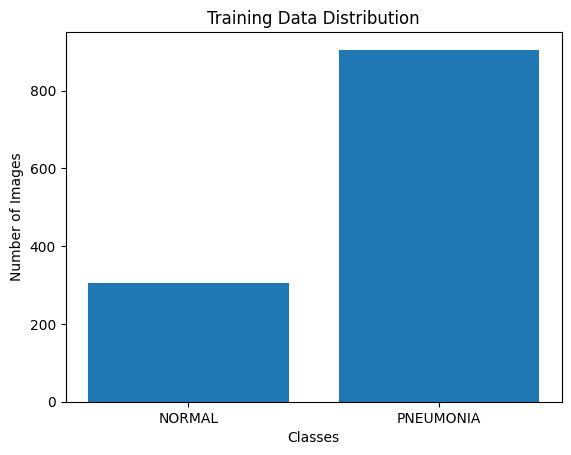

In [6]:
train_counts = {
    "NORMAL": len(os.listdir(train_dir+"/NORMAL")),
    "PNEUMONIA": len(os.listdir(train_dir+"/PNEUMONIA"))
}

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Data Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

The dataset contains more PNEUMONIA images than NORMAL images. This shows that the training data is not balanced, which may affect the model's learning and prediction performance.

# **Display Sample X-Ray Images**

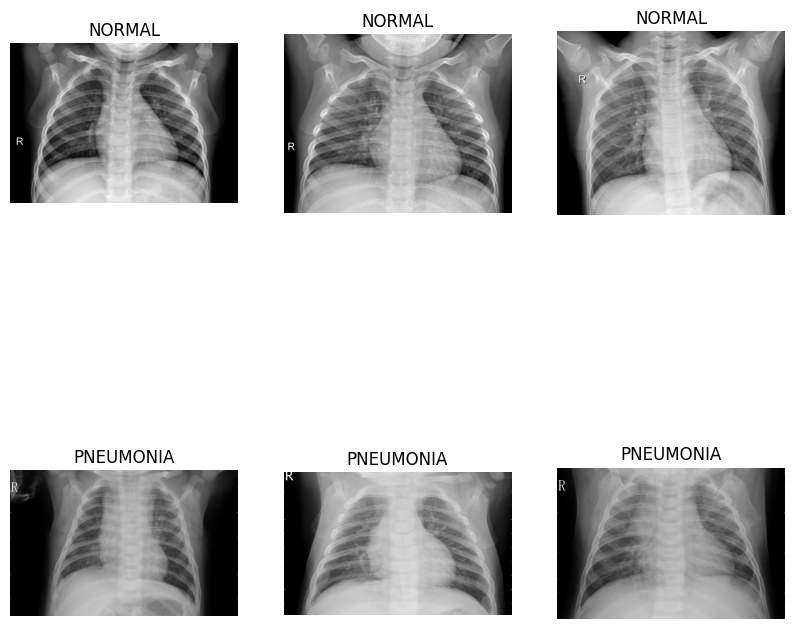

In [7]:
import random
import matplotlib.image as mpimg


plt.figure(figsize=(10,10))

normal_images = os.listdir(train_dir+"/NORMAL")
pneumonia_images = os.listdir(train_dir+"/PNEUMONIA")


for i in range(3):

    img_path = train_dir+"/NORMAL/"+random.choice(normal_images)

    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")


for i in range(3):

    img_path = train_dir+"/PNEUMONIA/"+random.choice(pneumonia_images)

    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+4)
    plt.imshow(img,cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.show()

# **Data Preprocessing**

In [8]:
#Image Parameters
IMG_SIZE = 224
BATCH_SIZE = 32

Data Augmentation

In [9]:
#For training images:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True)

In [10]:
#For validation and testing:
test_datagen = ImageDataGenerator(
    rescale=1./255)

# Load Images

In [11]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1207 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 518 images belonging to 2 classes.


In [12]:
#Check labels
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


# **Build CNN Model**

In [14]:
model = Sequential([
Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
MaxPooling2D(2,2),
Conv2D(64,(3,3),activation="relu"),
MaxPooling2D(2,2),
Conv2D(128,(3,3),activation="relu"),
MaxPooling2D(2,2),
Flatten(),
Dense(128,activation="relu"),
Dropout(0.5),
Dense(1,activation="sigmoid")])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
  )

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 325s 9s/step - accuracy: 0.5866 - loss: 0.7052 - val_accuracy: 0.6250 - val_loss: 0.6462
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7862 - loss: 0.4298 - val_accuracy: 0.6250 - val_loss: 0.9803
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8293 - loss: 0.3653 - val_accuracy: 0.7500 - val_loss: 0.5699
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8509 - loss: 0.3663 - val_accuracy: 0.7500 - val_loss: 0.4711
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8608 - loss: 0.3206 - val_accuracy: 0.6250 - val_loss: 0.8772
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8774 - loss: 0.2588 - val_accuracy: 0.6875 - val_loss: 0.9443
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8658 - loss: 0.3133 - val_accuracy: 0.7500 - val_loss: 0.9102
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8741 - loss: 0.3060 - val_accuracy: 0.7500 - val_los

Model Evaluation

In [17]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:",accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 162s 10s/step - accuracy: 0.8378 - loss: 0.5026
Test Accuracy: 0.837837815284729


# Performance **Visualization**

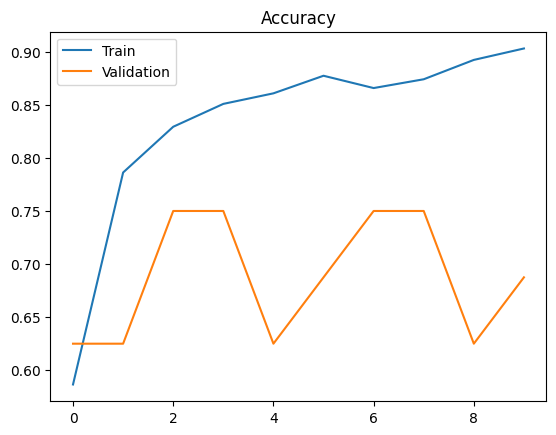

In [18]:
#Accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

The training accuracy keeps increasing, but the validation accuracy decreases after a few epochs. This means the model is overfitting. It learns the training data well but does not perform as well on new (validation) data.

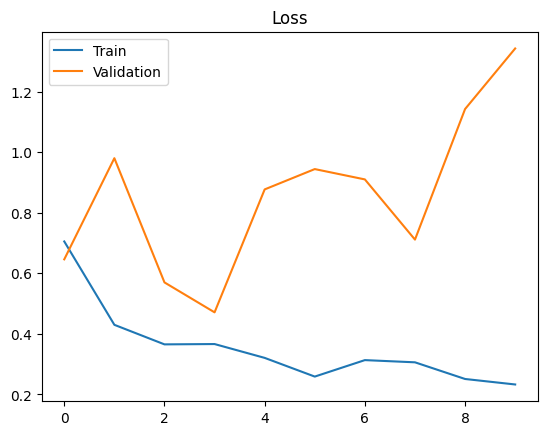

In [19]:
#Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [20]:
#Save Model
model.save("pneumonia_model.keras")

#**Improved CNN**
This model has an extra convolution layer and Batch Normalization.

In [21]:
from tensorflow.keras.layers import BatchNormalization

model2 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,033 (37.49 MB)

 Trainable params: 9,827,073 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
#compile
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
#Train:
history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.8111 - loss: 2.0716 - val_accuracy: 0.5000 - val_loss: 22.8013
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.8790 - loss: 0.2834 - val_accuracy: 0.5000 - val_loss: 39.4921
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.8956 - loss: 0.2390 - val_accuracy: 0.5000 - val_loss: 51.7902
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.9155 - loss: 0.2127 - val_accuracy: 0.5000 - val_loss: 38.1190
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.9105 - loss: 0.2411 - val_accuracy: 0.5000 - val_loss: 39.8225
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9271 - loss: 0.1798 - val_accuracy: 0.5000 - val_loss: 41.9396
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9188 - loss: 0.2092 - val_accuracy: 0.5000 - val_loss: 47.0734
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.9229 - loss: 0.2160 - val_accuracy: 0.5

#**MobileNetV2 (Transfer Learning)**

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model3 = Model(inputs=base_model.input, outputs=output)

model3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
#compile
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
#Train:
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7390 - loss: 0.5577 - val_accuracy: 0.5625 - val_loss: 0.6358
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8210 - loss: 0.3771 - val_accuracy: 0.6875 - val_loss: 0.5397
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8749 - loss: 0.3012 - val_accuracy: 0.6875 - val_loss: 0.4663
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8931 - loss: 0.2385 - val_accuracy: 0.6875 - val_loss: 0.5242
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9064 - loss: 0.2164 - val_accuracy: 0.7500 - val_loss: 0.4387
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9171 - loss: 0.2048 - val_accuracy: 0.7500 - val_loss: 0.5254
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9205 - loss: 0.2024 - val_accuracy: 0.7500 - val_loss: 0.4554
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9229 - loss: 0.1937 - val_accuracy: 0.7500 - val_loss:

Evaluate All Models

In [27]:
loss1, acc1 = model.evaluate(test_data)
loss2, acc2 = model2.evaluate(test_data)
loss3, acc3 = model3.evaluate(test_data)

print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)
print("Model 3 Accuracy:", acc3)

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 666ms/step - accuracy: 0.8378 - loss: 0.5026
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 823ms/step - accuracy: 0.5483 - loss: 73.6159
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 777ms/step - accuracy: 0.7799 - loss: 0.4887
Model 1 Accuracy: 0.837837815284729
Model 2 Accuracy: 0.5482625365257263
Model 3 Accuracy: 0.7799227833747864


# **Compare Results**

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Basic CNN", "Improved CNN", "MobileNetV2"],
    "Test Accuracy": [acc1, acc2, acc3]
})

print(results)

          Model  Test Accuracy
0     Basic CNN       0.837838
1  Improved CNN       0.548263
2   MobileNetV2       0.779923


# **Save the Best Model**

In [29]:
#Save the Best Model(Model1)
model.save("pneumonia_model.keras")

# **Prediciton**

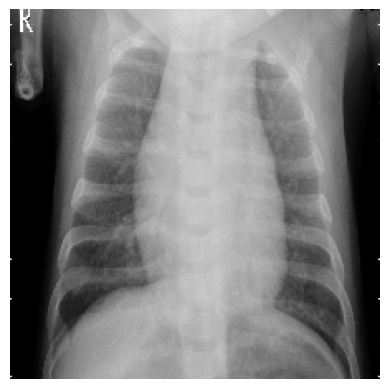

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: PNEUMONIA
Confidence: 99.97 %


In [31]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("pneumonia_model.keras")

# Path of the test image
img_path = "/content/drive/MyDrive/Deep_Learning_projects/chest_xray/test/PNEUMONIA/person1653_virus_2858.jpeg"

# Load and display the image
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess the image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Display result
if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
    print("Confidence:", round(prediction[0][0] * 100, 2), "%")
else:
    print("Prediction: NORMAL")
    print("Confidence:", round((1 - prediction[0][0]) * 100, 2), "%")


# **Conclusion**

Three models were evaluated for pneumonia detection: Basic CNN, Improved CNN, and MobileNetV2 using transfer learning. Among the evaluated models, the **Basic CNN achieved the highest test accuracy of 83.78%** on the given dataset. Therefore, the Basic CNN was selected as the final model and saved as `pneumonia_model.keras` for making predictions.
